Итого уникальных молекул после очистки: 2444
Генерация признаков...


[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerator
[00:30:01] DEPRECATION WARNING: please use MorganGenerat

Запуск кросс-валидации (5 фолдов)...

R2 по фолдам: [0.74451751 0.74403978 0.76707529 0.75349352 0.72418554]
Средний R2: 0.747 (+/- 0.028)

Обучение финальной модели на train/test split...


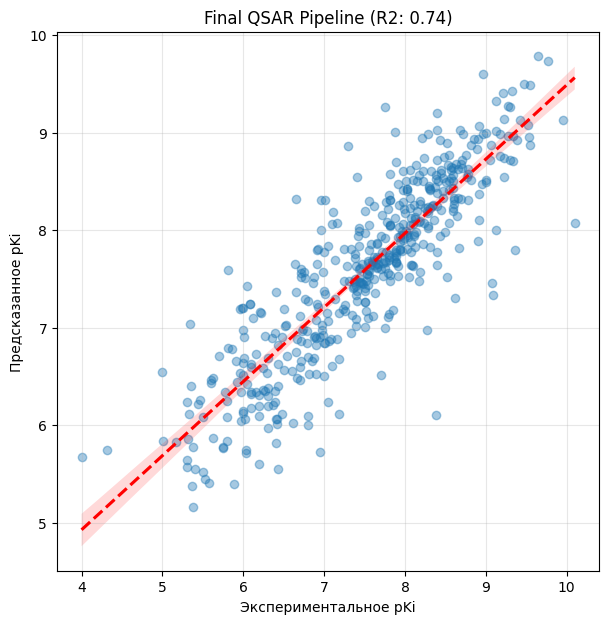

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, SaltRemover, Descriptors
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Чтобы графики отображались в IPython
%matplotlib inline

# ==========================================
# 1. ФУНКЦИИ ОЧИСТКИ И СТАНДАРТИЗАЦИИ
# ==========================================
remover = SaltRemover.SaltRemover()

def standardize_smiles(smiles):
    """Удаляет соли и приводит SMILES к каноническому виду."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        mol = remover.StripMol(mol)
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except:
        return None

def get_clean_data(file_path, std_threshold=0.1):
    """Загружает данные, применяет био-фильтры и убирает шумные дубликаты."""
    df = pd.read_csv(file_path, sep=';')
    
    # Биологические фильтры
    df = df[
        (df['Target Organism'] == 'Homo sapiens') & 
        (df['Assay Type'] == 'B') & 
        (df['Standard Type'] == 'Ki') & 
        (df['Data Validity Comment'].isna())
    ].copy()
    
    mask = df['Assay Description'].str.contains('radioligand|binding', case=False, na=False)
    df = df[mask]
    
    # Очистка структур
    df = df[['Smiles', 'pChEMBL Value']].dropna()
    df['Smiles'] = df['Smiles'].apply(standardize_smiles)
    df = df.dropna(subset=['Smiles'])
    
    # Агрегация дубликатов
    stats = df.groupby('Smiles')['pChEMBL Value'].agg(['median', 'std', 'count']).reset_index()
    stats['std'] = stats['std'].fillna(0)
    clean_df = stats[stats['std'] <= std_threshold].copy()
    
    print(f"Итого уникальных молекул после очистки: {len(clean_df)}")
    return clean_df.rename(columns={'median': 'target', 'Smiles': 'smiles'})

# ==========================================
# 2. ГЕНЕРАЦИЯ ПРИЗНАКОВ (FP + PhysChem)
# ==========================================
def get_combined_features(smiles):
    """Создает вектор из 1024 бит Morgan FP + 5 физ-хим свойств."""
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    
    # Morgan Fingerprint
    fp = list(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024))
    
    # 5 свойств Липинского
    physchem = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol)
    ]
    return fp + physchem

# ==========================================
# 3. ПОДГОТОВКА ДАННЫХ И КРОСС-ВАЛИДАЦИЯ
# ==========================================

# Замените 'chembl224.csv' на ваш путь к файлу
data = get_clean_data('chembl224.csv', std_threshold=0.1)

print("Генерация признаков...")
X_raw = np.array([get_combined_features(s) for s in data['smiles']])
y = data['target'].values

# Настройка препроцессора: масштабируем только последние 5 колонок (физ-хим свойства)
physchem_indices = list(range(1024, 1024 + 5))
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), physchem_indices)], 
    remainder='passthrough'
)

# Пайплайн для кросс-валидации (чтобы избежать утечки данных при масштабировании)
cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=10, epsilon=0.1, gamma=0.01))
])

# Кросс-валидация
print("Запуск кросс-валидации (5 фолдов)...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_raw, y, cv=kf, scoring='r2')

print(f"\nR2 по фолдам: {cv_scores}")
print(f"Средний R2: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# ==========================================
# 4. ФИНАЛЬНОЕ ОБУЧЕНИЕ И ВИЗУАЛИЗАЦИЯ
# ==========================================
print("\nОбучение финальной модели на train/test split...")
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Обучаем и трансформируем на тренировочных данных
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

final_model = SVR(kernel='rbf', C=10, epsilon=0.1, gamma=0.01)
final_model.fit(X_train_final, y_train)

y_pred = final_model.predict(X_test_final)

# График
plt.figure(figsize=(7,7))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4}, line_kws={'color':'red', 'ls':'--'})
plt.xlabel('Экспериментальное pKi')
plt.ylabel('Предсказанное pKi')
plt.title(f'Final QSAR Pipeline (R2: {r2_score(y_test, y_pred):.2f})')
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ------ --------------------------------- 16.5/101.7 MB 86.5 MB/s eta 0:00:01
   ------------ --------------------------- 31.5/101.7 MB 73.9 MB/s eta 0:00:01
   ------------------- -------------------- 49.8/101.7 MB 79.3 MB/s eta 0:00:01
   ----------------------- ---------------- 60.8/101.7 MB 73.0 MB/s eta 0:00:01
   --------------------------- ------------ 71.0/101.7 MB 67.6 MB/s eta 0:00:01
   ---------------------------------- ----- 87.6/101.7 MB 69.8 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 70.4 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 70.4 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 70.4 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 70.4 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 70.4 MB/s eta 0:00:01
   --------------------------------------  101.4/


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Anna_Maksymchuk1\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Обучение XGBoost...
R2 для XGBoost: 0.739
R2 для SVM (для справки): 0.745


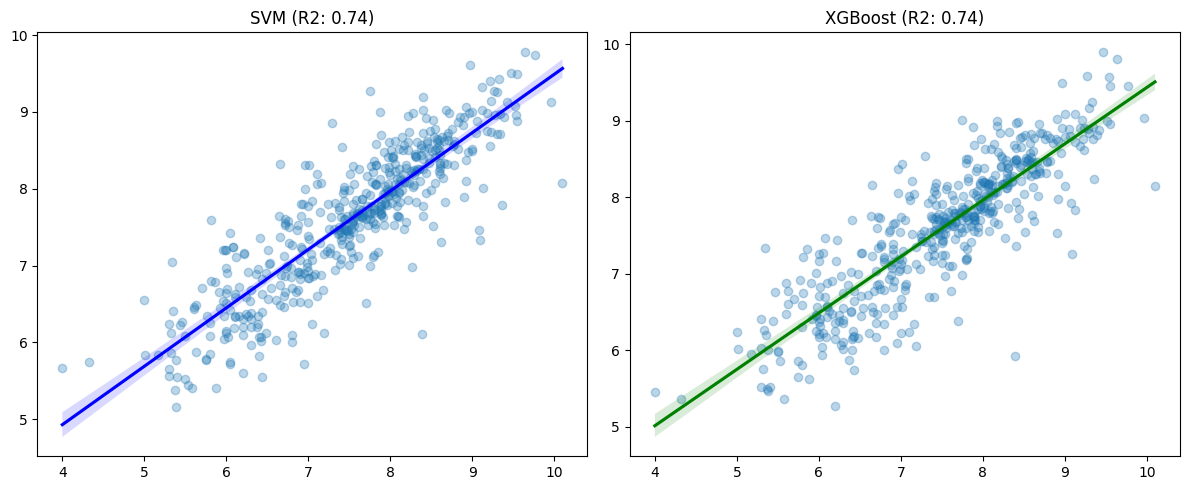

In [3]:
import xgboost as xgb
from sklearn.metrics import r2_score

# 1. Настройка модели XGBoost
# Для деревьев масштабирование не критично, но мы используем X_train_final 
# для честного сравнения с SVM на тех же данных.
xgb_model = xgb.XGBRegressor(
    n_estimators=500, # количество деревьев
    learning_rate=0.05, # скорость обучения
    max_depth=6, # глубина деревьев
    subsample=0.8, # использование 80% данных для каждого дерева (защита от переобучения)
    random_state=42,
    n_jobs=-1 # используем все ядра
)

# 2. Обучение
print("Обучение XGBoost...")
xgb_model.fit(X_train_final, y_train)

# 3. Предсказание и оценка
y_pred_xgb = xgb_model.predict(X_test_final)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"R2 для XGBoost: {r2_xgb:.3f}")
print(f"R2 для SVM (для справки): {r2_score(y_test, y_pred):.3f}")

# 4. Сравнительная визуализация
plt.figure(figsize=(12, 5))

# График для SVM
plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
plt.title(f'SVM (R2: {r2_score(y_test, y_pred):.2f})')

# График для XGBoost
plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_pred_xgb, scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title(f'XGBoost (R2: {r2_xgb:.2f})')

plt.tight_layout()
plt.show()

C:\Users\Anna_Maksymchuk1\AppData\Local\Temp\ipykernel_892\4247480710.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Importance', y='Feature', palette='magma')


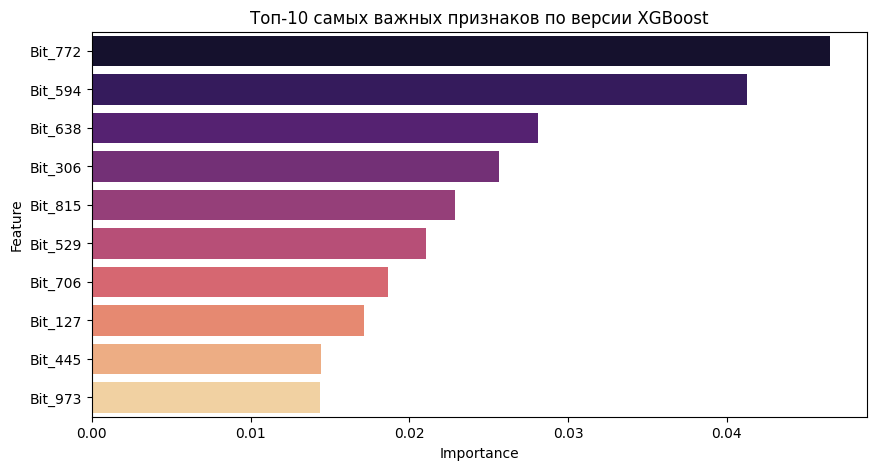

In [4]:
# Посмотрим на топ-10 важных признаков
importances = xgb_model.feature_importances_
# Названия: биты + 5 свойств
feature_names = [f'Bit_{i}' for i in range(1024)] + ['MW', 'LogP', 'HBD', 'HBA', 'TPSA']

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10 = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x='Importance', y='Feature', palette='magma')
plt.title('Топ-10 самых важных признаков по версии XGBoost')
plt.show()

In [6]:
from rdkit.Chem import Draw

def visualize_important_bit(smiles, bit_id, radius=2):
    mol = Chem.MolFromSmiles(smiles)
    info = {}
    # Генерируем FP с сохранением информации о фрагментах
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=1024, bitInfo=info)
    
    if bit_id in info:
        print(f"Бит {bit_id} найден в молекуле!")
        return Draw.DrawMorganBit(mol, bit_id, info)
    else:
        return "Бит не найден в этой молекуле"

# Пример: возьмем самую активную молекулу и посмотрим в ней важный бит (например, Bit_42)
top_smiles = data.sort_values('target', ascending=False).iloc[0]['smiles']
visualize_important_bit(top_smiles, bit_id=42)

[01:42:03] DEPRECATION WARNING: please use MorganGenerator


'Бит не найден в этой молекуле'

In [ ]:
from sklearn.inspection import permutation_importance

# Рассчитываем важность на тестовой выборке
result = permutation_importance(final_model, X_test_final, y_test, n_repeats=10, random_state=42)

# Названия наших физ-хим свойств
physchem_names = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA']

# Сопоставляем важность последним 5 колонкам
importances = result.importances_mean[-5:]

print("Вклад физико-химических свойств в модель:")
for name, imp in zip(physchem_names, importances):
    print(f"{name}: {imp:.4f}")

# Визуализация
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=physchem_names, palette='viridis')
plt.title('Важность физико-химических дескрипторов')
plt.xlabel('Падение R2 при исключении признака')
plt.show()